In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt


os.getcwd()

'C:\\Users\\aabha'

In [2]:
pwd

'C:\\Users\\aabha'

In [3]:
# import pandas as pd
# df=pd.read_csv("maternal mortality data")

# print(df.shape)
# df.head()

In [4]:
# os.listdir()

In [5]:
df = pd.read_csv(
    "Maternal Mortality PRAMS.csv"
)

print(df.shape)
df.head()

(226, 168)


,Site Name,Year,Deaths/100000,Multivitamin use ≥4 times a week during the month before pregnancy - Unweighted Sample Size,Multivitamin use ≥4 times a week during the month before pregnancy - Unweighted Frequency,Multivitamin use ≥4 times a week during the month before pregnancy - Weighted %,Multivitamin use ≥4 times a week during the month before pregnancy - Lower 95%\nConfidence Interval,Multivitamin use ≥4 times a week during the month before pregnancy - Upper 95%\nConfidence Interval,Underweight (body mass index [BMI] <18.5 kg/m2) - Unweighted Sample Size,Underweight (body mass index [BMI] <18.5 kg/m2) - Unweighted Frequency,...,Medicaid or CHIP/SCHIP - Unweighted Sample Size,Medicaid or CHIP/SCHIP - Unweighted Frequency,Medicaid or CHIP/SCHIP - Weighted %,Medicaid or CHIP/SCHIP - Lower 95%\nConfidence Interval,Medicaid or CHIP/SCHIP - Upper 95%\nConfidence Interval,No insurance - Unweighted Sample Size,No insurance - Unweighted Frequency,No insurance - Weighted %,No insurance - Lower 95%\nConfidence Interval,No insurance - Upper 95%\nConfidence Interval
0,Alaska,2016,NaN,1165,435,40.5,37.0,44.0,1144,34,...,1143,304,23.2,20.6,26.1,1143,228,17.7,15.2,20.4
1,Arkansas,2016,17.0,901,298,35.9,31.4,40.7,864,42,...,785,247,24.2,20.0,28.9,785,70,11.0,8.0,14.8
2,Colorado,2016,16.0,1619,753,43.2,39.9,46.7,1528,63,...,1538,359,24.1,21.1,27.3,1538,132,9.5,7.5,12.1
3,Connecticut,2016,NaN,1286,543,47.8,44.5,51.1,1232,46,...,1263,317,23.2,20.6,26.0,1263,149,9.4,8.0,11.1
4,Delaware,2016,NaN,928,405,41.8,38.5,45.1,876,29,...,898,278,31.1,27.9,34.4,898,81,9.1,7.3,11.3


In [6]:
import fnmatch
fnmatch.filter(df,'Multivitamin *')

['Multivitamin use ≥4 times a week during the month before pregnancy - Unweighted Sample Size ',
 'Multivitamin use ≥4 times a week during the month before pregnancy - Unweighted Frequency  ',
 'Multivitamin use ≥4 times a week during the month before pregnancy - Weighted %',
 'Multivitamin use ≥4 times a week during the month before pregnancy -  Lower 95%\nConfidence Interval',
 'Multivitamin use ≥4 times a week during the month before pregnancy - Upper 95%\nConfidence Interval']

In [7]:
cols = [
    "Site Name",
    "Year",
    "Deaths/100000"
]

df_maternal = df[cols]
print(df_maternal.shape)
df_maternal.head()

(226, 3)


,Site Name,Year,Deaths/100000
0,Alaska,2016,NaN
1,Arkansas,2016,17.0
2,Colorado,2016,16.0
3,Connecticut,2016,NaN
4,Delaware,2016,NaN


In [8]:
df_maternal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Site Name      226 non-null    object 
 1   Year           226 non-null    int64  
 2   Deaths/100000  138 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.4+ KB


In [9]:
df_maternal = df_maternal.rename(columns={
    "Site Name": "State",
    "Deaths/100000": "Maternal Mortality Rate"
})

print(df_maternal.shape)
df_maternal.head()

(226, 3)


,State,Year,Maternal Mortality Rate
0,Alaska,2016,NaN
1,Arkansas,2016,17.0
2,Colorado,2016,16.0
3,Connecticut,2016,NaN
4,Delaware,2016,NaN


In [10]:
# Checking for any NaN values in datframe - df
df_maternal.isna().sum()
# df_maternal.isna().sum().sum()

State                       0
Year                        0
Maternal Mortality Rate    88
dtype: int64

In [11]:
(88/226)*100

38.93805309734513

In [12]:
df_maternal['Maternal Mortality Rate'].isna().sum()

np.int64(88)

In [13]:
# Frequecy distribution of feature 'Year' in df and sorting by index.
df_maternal.Year.value_counts().sort_index()

Year
2016    30
2017    35
2018    42
2019    42
2020    41
2021    36
Name: count, dtype: int64

In [14]:
df_maternal['Maternal Mortality Rate'].describe()
# df_maternal.describe()

count    138.000000
mean      29.521739
std       20.996078
min        0.000000
25%       16.000000
50%       24.000000
75%       39.000000
max      153.000000
Name: Maternal Mortality Rate, dtype: float64

In [15]:
# df_maternal.describe().T

In [16]:
df_maternal["Maternal Mortality Rate"].quantile(
    [0.05,0.25,0.50,0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.0]
)

0.05     10.00
0.25     16.00
0.50     24.00
0.70     35.90
0.75     39.00
0.80     41.00
0.85     46.45
0.90     54.60
0.95     65.15
0.99     93.41
1.00    153.00
Name: Maternal Mortality Rate, dtype: float64

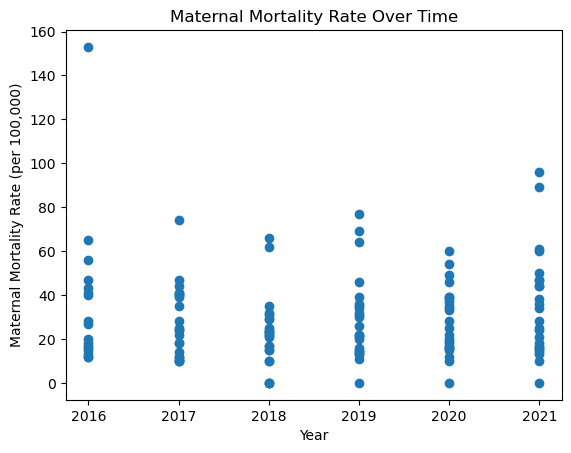

In [17]:
plt.scatter(df_maternal["Year"], df_maternal["Maternal Mortality Rate"])
plt.xlabel("Year")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.title("Maternal Mortality Rate Over Time")

plt.show()

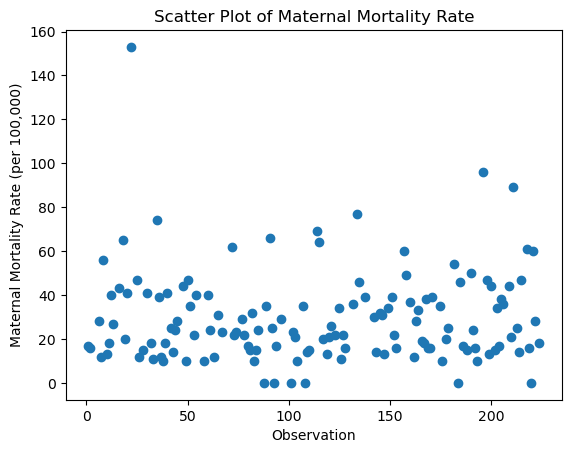

In [18]:
plt.scatter(
    range(len(df_maternal["Maternal Mortality Rate"])),
    df_maternal["Maternal Mortality Rate"]
)

plt.xlabel("Observation")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.title("Scatter Plot of Maternal Mortality Rate")

plt.show()

In [19]:
print(df_maternal.shape)
df_maternal.head()

(226, 3)


,State,Year,Maternal Mortality Rate
0,Alaska,2016,NaN
1,Arkansas,2016,17.0
2,Colorado,2016,16.0
3,Connecticut,2016,NaN
4,Delaware,2016,NaN


In [20]:
df_maternal["Maternal Mortality Rate"].median()

24.0

In [21]:
# Fill missing values in "Maternal Mortality Rate" with the median : Imputation
df_maternal["Maternal Mortality Rate"] = df_maternal["Maternal Mortality Rate"].fillna(
    df_maternal["Maternal Mortality Rate"].median()
)

In [22]:
print(df_maternal.shape)
df_maternal.head()

(226, 3)


,State,Year,Maternal Mortality Rate
0,Alaska,2016,24.0
1,Arkansas,2016,17.0
2,Colorado,2016,16.0
3,Connecticut,2016,24.0
4,Delaware,2016,24.0


In [23]:
df_maternal["Maternal Mortality Rate"].quantile(
    [0.05,0.25,0.50,0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.0]
)

0.05     10.00
0.25     21.00
0.50     24.00
0.70     24.00
0.75     28.75
0.80     35.00
0.85     39.00
0.90     45.00
0.95     60.00
0.99     86.00
1.00    153.00
Name: Maternal Mortality Rate, dtype: float64

In [24]:
df_clean = df_maternal.copy()

In [25]:
# df_clean['MMR_Capped'] = df_clean['Maternal Mortality Rate'].clip(lower=10, upper=90)

In [26]:
df_clean['MMR_Capped'] = df_clean["Maternal Mortality Rate"].clip(lower=10, upper=90)
print(df_clean.shape)
df_clean.head()

# Lower value = Flooring
# Upper value = CApping

(226, 4)


,State,Year,Maternal Mortality Rate,MMR_Capped
0,Alaska,2016,24.0,24.0
1,Arkansas,2016,17.0,17.0
2,Colorado,2016,16.0,16.0
3,Connecticut,2016,24.0,24.0
4,Delaware,2016,24.0,24.0


In [27]:
df_clean[['Maternal Mortality Rate', 'MMR_Capped']].head()

,Maternal Mortality Rate,MMR_Capped
0,24.0,24.0
1,17.0,17.0
2,16.0,16.0
3,24.0,24.0
4,24.0,24.0


In [28]:
# df_clean['Maternal Mortality Rate'] = df_clean['Maternal Mortality Rate'].clip(lower=10, upper=90)

In [29]:
df_clean[['MMR_Capped','Maternal Mortality Rate']].agg(['min','max'])

,MMR_Capped,Maternal Mortality Rate
min,10.0,0.0
max,90.0,153.0


In [30]:
df_clean["Maternal Mortality Rate"].quantile(
    [0.05,0.25,0.50,0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.0]
)

0.05     10.00
0.25     21.00
0.50     24.00
0.70     24.00
0.75     28.75
0.80     35.00
0.85     39.00
0.90     45.00
0.95     60.00
0.99     86.00
1.00    153.00
Name: Maternal Mortality Rate, dtype: float64

In [31]:
df_clean.head()

,State,Year,Maternal Mortality Rate,MMR_Capped
0,Alaska,2016,24.0,24.0
1,Arkansas,2016,17.0,17.0
2,Colorado,2016,16.0,16.0
3,Connecticut,2016,24.0,24.0
4,Delaware,2016,24.0,24.0


In [32]:
df_clean.State.nunique() # Unique value

47

In [33]:
# df_clean = df_maternal.dropna(subset=["Maternal Mortality Rate"])
# print(df_clean.shape)
# df_clean.head()

In [34]:
# 226-138

In [35]:
88/226

0.3893805309734513

In [36]:
# df_maternal.shape

In [37]:
# df_maternal['Maternal Mortality Rate'].describe()

In [38]:
# Flooring andCapping
# Imputation

In [39]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    226 non-null    object 
 1   Year                     226 non-null    int64  
 2   Maternal Mortality Rate  226 non-null    float64
 3   MMR_Capped               226 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 7.2+ KB


In [40]:
df_clean.loc[df_clean['State'] == 'Arkansas']

,State,Year,Maternal Mortality Rate,MMR_Capped
1,Arkansas,2016,17.0,17.0
67,Arkansas,2018,23.0,23.0
109,Arkansas,2019,14.0,14.0
152,Arkansas,2020,22.0,22.0
191,Arkansas,2021,24.0,24.0


In [41]:
df_clean.loc[df_clean['State'] == 'Arkansas', 'Maternal Mortality Rate'].mean()

np.float64(20.0)

In [42]:
df_subset = df_clean[
    df_clean["State"].isin(
        ["Arkansas", "Colorado", "Illinois", "Iowa", "Louisiana"]
    )
]

state_avg = (
    df_subset
    .groupby("State")["Maternal Mortality Rate"]
    .mean()
    .reset_index()
)

state_avg

,State,Maternal Mortality Rate
0,Arkansas,20.000000
1,Colorado,17.500000
2,Illinois,32.166667
3,Iowa,19.200000
4,Louisiana,37.000000


In [43]:
import pandas as pd

In [44]:
import os
os.listdir()

['.affinity',
 '.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.git',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lesshst',
 '.matplotlib',
 '.ms-ad',
 '.spss',
 'anaconda3',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Data-science-',
 'DaVinci Resolve Media',
 'Documents',
 'Downloads',
 'Favorites',
 'gbsg.csv',
 'gbsg.ipynb',
 'grades.csv',
 'Links',
 'Local Settings',
 'Maternal Mortality PRAMS.csv',
 'MaternalMortality.ipynb',
 'Muse Hub',
 'Music',
 'My Documents',
 'MyFirstPython.ipynb',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{5dc45d5c-502f-11f0-8116-8c47be171a1b}.TM.blf',
 'NTUSER.DAT{5dc45d5c-502f-11f0-8116-8c47be171a1b}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{5dc45d5c-502f-11f0-8116-8c47be171a1b}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.i

In [45]:
df = pd.read_csv("PRAMS_MCH_Indicators_2016_2021_Final - PRAMS_MCH_Indicators_2016_2021_merged_new (1).csv")

FileNotFoundError: [Errno 2] No such file or directory: 'PRAMS_MCH_Indicators_2016_2021_Final - PRAMS_MCH_Indicators_2016_2021_merged_new (1).csv'

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
cols = [
    'Site Name',
    'Year',
    'Deaths/100000',
    'Multivitamin use ≥4 times a week during the month before pregnancy - Weighted %',
    'Underweight (body mass index [BMI] <18.5 kg/m2) - Weighted %',
    'Medicaid or CHIP/SCHIP - Weighted %'
]

analysis_df = df[cols].copy()
analysis_df.head()

In [ ]:
analysis_df.corr(numeric_only=True)

In [ ]:
import statsmodels.api as sm

X = analysis_df[[
    'Multivitamin use ≥4 times a week during the month before pregnancy - Weighted %',
    'Underweight (body mass index [BMI] <18.5 kg/m2) - Weighted %',
    'Medicaid or CHIP/SCHIP - Weighted %'
]]

X = sm.add_constant(X)

y = analysis_df['Deaths/100000']

model = sm.OLS(y, X).fit()
print(model.summary())

In [ ]:
analysis_df.isna().sum()